In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
import json
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith((".parquet", ".csv", ".json")):
            print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/notjustauser/04-lstm/lstm_horizon_metrics.csv
/kaggle/input/notebooks/notjustauser/04-lstm/lstm_predictions.parquet
/kaggle/input/notebooks/notjustauser/04-lstm/lstm_metrics.csv
/kaggle/input/notebooks/notjustauser/04-lstm/lstm_config.json
/kaggle/input/notebooks/notjustauser/04-lstm/__output__.json
/kaggle/input/notebooks/notjustauser/03-baselines/baseline_horizon_metrics_12utc.csv
/kaggle/input/notebooks/notjustauser/03-baselines/baseline_horizon_metrics.csv
/kaggle/input/notebooks/notjustauser/03-baselines/baseline_metrics_12utc.csv
/kaggle/input/notebooks/notjustauser/03-baselines/baseline_predictions.parquet
/kaggle/input/notebooks/notjustauser/03-baselines/baseline_metrics.csv
/kaggle/input/notebooks/notjustauser/03-baselines/operational_baseline_config.json
/kaggle/input/notebooks/notjustauser/03-baselines/__output__.json
/kaggle/input/notebooks/notjustauser/03-baselines/split_config.json
/kaggle/input/notebooks/notjustauser/03-baselines/baseline_predicti

In [2]:
BASELINE_PATH = Path(
    "/kaggle/input/notebooks/notjustauser/"
    "03-baselines/baseline_predictions.parquet"
)

LSTM_PATH = Path(
    "/kaggle/input/notebooks/notjustauser/"
    "04-lstm/lstm_predictions.parquet"
)

CNN_PATH = Path(
    "/kaggle/input/notebooks/notjustauser/"
    "05-cnn-lstm/cnn_lstm_predictions.parquet"
)

CNN_CONFIG_PATH = Path(
    "/kaggle/input/notebooks/notjustauser/"
    "05-cnn-lstm/cnn_lstm_config.json"
)

INPUT_PATHS = {
    "baseline predictions": BASELINE_PATH,
    "LSTM predictions": LSTM_PATH,
    "CNN-LSTM predictions": CNN_PATH,
    "CNN-LSTM configuration": CNN_CONFIG_PATH,
}

for name, path in INPUT_PATHS.items():
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {name}: {path}"
        )

print("All Notebook 6 input files exist.")

All Notebook 6 input files exist.


In [3]:
baseline = pd.read_parquet(
    BASELINE_PATH
)

lstm = pd.read_parquet(
    LSTM_PATH
)

cnn = pd.read_parquet(
    CNN_PATH
)

with open(
    CNN_CONFIG_PATH,
    "r"
) as file:
    cnn_config = json.load(file)

print("Baseline shape:", baseline.shape)
print("LSTM shape:", lstm.shape)
print("CNN-LSTM shape:", cnn.shape)

display(baseline.head())
display(lstm.head())
display(cnn.head())

print("CNN-LSTM configuration:")
display(cnn_config)

Baseline shape: (62568, 5)
LSTM shape: (62568, 4)
CNN-LSTM shape: (62568, 4)


,forecast_start,horizon,actual,daily_naive,weekly_naive
0,2024-05-15 05:00:00+00:00,1,88.160004,77.330002,118.959999
1,2024-05-15 05:00:00+00:00,2,84.449997,51.500000,110.120003
2,2024-05-15 05:00:00+00:00,3,48.419998,5.640000,92.410004
3,2024-05-15 05:00:00+00:00,4,7.360000,-2.330000,85.400002
4,2024-05-15 05:00:00+00:00,5,-0.080000,-11.120000,79.480003


,forecast_start,horizon,actual,lstm
0,2024-05-15 05:00:00+00:00,1,88.160004,108.561241
1,2024-05-15 05:00:00+00:00,2,84.449997,111.642334
2,2024-05-15 05:00:00+00:00,3,48.420002,98.802559
3,2024-05-15 05:00:00+00:00,4,7.360003,73.431206
4,2024-05-15 05:00:00+00:00,5,-0.080000,58.398640


,forecast_start,horizon,actual,cnn_lstm
0,2024-05-15 05:00:00+00:00,1,88.160004,79.541084
1,2024-05-15 05:00:00+00:00,2,84.449997,74.046799
2,2024-05-15 05:00:00+00:00,3,48.420002,63.058208
3,2024-05-15 05:00:00+00:00,4,7.360003,49.353748
4,2024-05-15 05:00:00+00:00,5,-0.080000,40.359875


CNN-LSTM configuration:


{'contract_version': 1,
 'model_version': 'cnn_lstm_v1_frozen',
 'model': 'CNN-LSTM',
 'model_format': 'keras',
 'lookback': 168,
 'horizon': 24,
 'input_shape': [168, 15],
 'output_shape': [24],
 'target_col': 'price_eur_mwh',
 'features_cols': ['load_actual_mwh',
  'load_forecast_mwh',
  'hour_sin',
  'hour_cos',
  'dow_sin',
  'dow_cos',
  'weekend',
  'price_lag_1',
  'price_lag_24',
  'price_lag_48',
  'price_lag_168',
  'price_roll_mean_24',
  'price_roll_std_24',
  'price_roll_mean_168',
  'price_roll_std_168'],
 'conv1_filters': 32,
 'conv1_kernel': 3,
 'pool_size': 2,
 'conv2_filters': 32,
 'conv2_kernel': 3,
 'padding': 'causal',
 'lstm_units': 64,
 'lstm_dropout': 0.2,
 'dense_units': 64,
 'dense_dropout': 0.2,
 'optimizer': 'Adam',
 'learning_rate': 0.001,
 'loss': 'Huber',
 'batch_size': 64,
 'max_epochs': 125,
 'seed': 56,
 'canonical_timezone': 'UTC',
 'display_timezone': 'Europe/Berlin',
 'input_frequency': '1h',
 'scheduled_forecast_hour_utc': 12,
 'minimum_raw_history

In [4]:
FRAME_SPECIFICATIONS = {
    "baseline": {
        "frame": baseline,
        "prediction_columns": [
            "daily_naive",
            "weekly_naive"
        ]
    },

    "lstm": {
        "frame": lstm,
        "prediction_columns": [
            "lstm"
        ]
    },

    "cnn_lstm": {
        "frame": cnn,
        "prediction_columns": [
            "cnn_lstm"
        ]
    }
}

for name, specification in (
    FRAME_SPECIFICATIONS.items()
):

    frame = specification["frame"]
    prediction_columns = (
        specification[
            "prediction_columns"
        ]
    )

    required_columns = [
        "forecast_start",
        "horizon",
        "actual",
        *prediction_columns
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in frame.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{name} is missing columns: "
            f"{missing_columns}"
        )

    frame["forecast_start"] = (
        pd.to_datetime(
            frame["forecast_start"],
            utc=True,
            errors="raise"
        )
    )

    frame["horizon"] = (
        pd.to_numeric(
            frame["horizon"],
            errors="raise"
        )
        .astype(int)
    )

    if frame[
        [
            "forecast_start",
            "horizon"
        ]
    ].isna().any().any():

        raise ValueError(
            f"{name} contains missing keys."
        )

    duplicate_count = (
        frame.duplicated(
            subset=[
                "forecast_start",
                "horizon"
            ]
        ).sum()
    )

    if duplicate_count:
        raise ValueError(
            f"{name} contains "
            f"{duplicate_count} duplicate keys."
        )

    value_columns = [
        "actual",
        *prediction_columns
    ]

    if frame[
        value_columns
    ].isna().any().any():

        raise ValueError(
            f"{name} contains missing "
            "actual or prediction values."
        )

    horizon_validation = (
        frame
        .groupby("forecast_start")
        .agg(
            row_count=(
                "horizon",
                "size"
            ),

            unique_horizons=(
                "horizon",
                "nunique"
            ),

            minimum_horizon=(
                "horizon",
                "min"
            ),

            maximum_horizon=(
                "horizon",
                "max"
            )
        )
    )

    complete_forecasts = (
        horizon_validation[
            "row_count"
        ].eq(24)
        & horizon_validation[
            "unique_horizons"
        ].eq(24)
        & horizon_validation[
            "minimum_horizon"
        ].eq(1)
        & horizon_validation[
            "maximum_horizon"
        ].eq(24)
    )

    if not complete_forecasts.all():
        raise ValueError(
            f"{name} contains incomplete "
            "24-hour forecasts."
        )

    print(
        name,
        "validated forecasts:",
        frame[
            "forecast_start"
        ].nunique()
    )

baseline validated forecasts: 2607
lstm validated forecasts: 2607
cnn_lstm validated forecasts: 2607


In [5]:
EXPECTED_CONFIG = {
    "lookback": 168,
    "horizon": 24,
    "conv1_filters": 32,
    "conv2_filters": 32,
    "lstm_units": 64,
}

for key, expected_value in (
    EXPECTED_CONFIG.items()
):

    received_value = (
        cnn_config.get(key)
    )

    if received_value != expected_value:
        raise ValueError(
            f"Incorrect CNN configuration "
            f"for '{key}'. "
            f"Expected {expected_value}, "
            f"received {received_value}."
        )

print(
    "CNN-LSTM configuration validated."
)

CNN-LSTM configuration validated.


In [6]:
KEY_COLUMNS = [
    "forecast_start",
    "horizon"
]

reference_keys = (
    baseline[KEY_COLUMNS]
    .sort_values(KEY_COLUMNS)
    .reset_index(drop=True)
)

for name, frame in {
    "lstm": lstm,
    "cnn_lstm": cnn
}.items():

    comparison_keys = (
        frame[KEY_COLUMNS]
        .sort_values(KEY_COLUMNS)
        .reset_index(drop=True)
    )

    pd.testing.assert_frame_equal(
        reference_keys,
        comparison_keys,
        check_dtype=False,
        obj=f"{name} forecast keys"
    )

# Confirm that every file contains the same actual prices.
actual_comparison = (
    baseline[
        KEY_COLUMNS + ["actual"]
    ]
    .rename(
        columns={
            "actual":
                "actual_baseline"
        }
    )
    .merge(
        lstm[
            KEY_COLUMNS + ["actual"]
        ].rename(
            columns={
                "actual":
                    "actual_lstm"
            }
        ),
        on=KEY_COLUMNS,
        how="inner",
        validate="one_to_one"
    )
    .merge(
        cnn[
            KEY_COLUMNS + ["actual"]
        ].rename(
            columns={
                "actual":
                    "actual_cnn_lstm"
            }
        ),
        on=KEY_COLUMNS,
        how="inner",
        validate="one_to_one"
    )
)

np.testing.assert_allclose(
    actual_comparison[
        "actual_baseline"
    ],
    actual_comparison[
        "actual_lstm"
    ],
    rtol=1e-5,
    atol=1e-3
)

np.testing.assert_allclose(
    actual_comparison[
        "actual_baseline"
    ],
    actual_comparison[
        "actual_cnn_lstm"
    ],
    rtol=1e-5,
    atol=1e-3
)

common = (
    baseline[
        KEY_COLUMNS
        + [
            "actual",
            "daily_naive",
            "weekly_naive"
        ]
    ]
    .merge(
        lstm[
            KEY_COLUMNS + ["lstm"]
        ],
        on=KEY_COLUMNS,
        how="inner",
        validate="one_to_one"
    )
    .merge(
        cnn[
            KEY_COLUMNS
            + ["cnn_lstm"]
        ],
        on=KEY_COLUMNS,
        how="inner",
        validate="one_to_one"
    )
    .sort_values(KEY_COLUMNS)
    .reset_index(drop=True)
)

if len(common) != len(baseline):
    raise ValueError(
        "Rows were lost during merging."
    )

print("Validated common rows:", len(common))
display(common.head())

Validated common rows: 62568


,forecast_start,horizon,actual,daily_naive,weekly_naive,lstm,cnn_lstm
0,2024-05-15 05:00:00+00:00,1,88.160004,77.330002,118.959999,108.561241,79.541084
1,2024-05-15 05:00:00+00:00,2,84.449997,51.500000,110.120003,111.642334,74.046799
2,2024-05-15 05:00:00+00:00,3,48.419998,5.640000,92.410004,98.802559,63.058208
3,2024-05-15 05:00:00+00:00,4,7.360000,-2.330000,85.400002,73.431206,49.353748
4,2024-05-15 05:00:00+00:00,5,-0.080000,-11.120000,79.480003,58.398640,40.359875


In [7]:
display(common.head())
print(common.shape)

print("Baseline rows:", len(baseline))
print("LSTM rows:", len(lstm))
print("CNN-LSTM rows:", len(cnn))
print("Common rows:", len(common))

,forecast_start,horizon,actual,daily_naive,weekly_naive,lstm,cnn_lstm
0,2024-05-15 05:00:00+00:00,1,88.160004,77.330002,118.959999,108.561241,79.541084
1,2024-05-15 05:00:00+00:00,2,84.449997,51.500000,110.120003,111.642334,74.046799
2,2024-05-15 05:00:00+00:00,3,48.419998,5.640000,92.410004,98.802559,63.058208
3,2024-05-15 05:00:00+00:00,4,7.360000,-2.330000,85.400002,73.431206,49.353748
4,2024-05-15 05:00:00+00:00,5,-0.080000,-11.120000,79.480003,58.398640,40.359875


(62568, 7)
Baseline rows: 62568
LSTM rows: 62568
CNN-LSTM rows: 62568
Common rows: 62568


In [8]:
common_forecasts = (
    common["forecast_start"]
    .nunique()
)

print(
    "Common 24-hour forecasts:",
    common_forecasts
)

Common 24-hour forecasts: 2607


In [9]:
print(
    "Expected rows:",
    common_forecasts * 24
)

print(
    "Actual rows:",
    len(common)
)

Expected rows: 62568
Actual rows: 62568


In [10]:
horizon_count = (
    common.groupby("forecast_start")["horizon"]
    .nunique()
)

print(
    horizon_count.value_counts()
)

horizon
24    2607
Name: count, dtype: int64


In [11]:
MAPE_MIN_ABS_ACTUAL = 1.0


def smape(
    y_true,
    y_pred,
    eps=1e-6
):
    y_true = np.asarray(
        y_true,
        dtype=float
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float
    )

    denominator = (
        np.abs(y_true)
        + np.abs(y_pred)
        + eps
    )

    return float(
        100
        * np.mean(
            2
            * np.abs(
                y_pred - y_true
            )
            / denominator
        )
    )


def guarded_mape(
    y_true,
    y_pred,
    min_abs_actual=MAPE_MIN_ABS_ACTUAL
):
    y_true = np.asarray(
        y_true,
        dtype=float
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float
    )

    valid = (
        np.abs(y_true)
        >= min_abs_actual
    )

    excluded = int(
        (~valid).sum()
    )

    if valid.sum() == 0:
        return None, excluded

    score = (
        100
        * np.mean(
            np.abs(
                (
                    y_true[valid]
                    - y_pred[valid]
                )
                / y_true[valid]
            )
        )
    )

    return float(score), excluded


def evaluate(
    y_true,
    y_pred
):
    y_true = np.asarray(
        y_true,
        dtype=float
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float
    )

    finite = (
        np.isfinite(y_true)
        & np.isfinite(y_pred)
    )

    if finite.sum() == 0:
        raise ValueError(
            "No valid observations "
            "are available."
        )

    y_true = y_true[finite]
    y_pred = y_pred[finite]

    score_mape, excluded = (
        guarded_mape(
            y_true,
            y_pred
        )
    )

    return {
        "N": int(len(y_true)),

        "MAE": float(
            mean_absolute_error(
                y_true,
                y_pred
            )
        ),

        "RMSE": float(
            np.sqrt(
                mean_squared_error(
                    y_true,
                    y_pred
                )
            )
        ),

        "sMAPE": smape(
            y_true,
            y_pred
        ),

        "MAPE_guarded":
            score_mape,

        "MAPE_excluded":
            excluded
    }

In [12]:
model_cols = {
    "Daily naive": "daily_naive",
    "Weekly naive": "weekly_naive",
    "LSTM": "lstm",
    "CNN-LSTM": "cnn_lstm"
}

In [13]:
result_rows = []

for model_name, col in model_cols.items():

    scores = evaluate(
        common["actual"],
        common[col]
    )

    result_rows.append(
        {
            "model": model_name,
            **scores
        }
    )

final_metrics = pd.DataFrame(
    result_rows
)

In [14]:
display(
    final_metrics.sort_values("MAE")
)

,model,N,MAE,RMSE,sMAPE,MAPE_guarded,MAPE_excluded
3,CNN-LSTM,62568,21.367295,28.671335,46.990888,109.399248,3336
2,LSTM,62568,22.423798,29.913783,46.865641,121.750488,3336
1,Weekly naive,62568,27.330710,37.185778,62.341744,114.633077,3336
0,Daily naive,62568,27.346263,38.609787,60.742546,112.829501,3336


In [15]:
lstm_mae = final_metrics.loc[
    final_metrics["model"] == "LSTM",
    "MAE"
].iloc[0]

cnn_mae = final_metrics.loc[
    final_metrics["model"] == "CNN-LSTM",
    "MAE"
].iloc[0]

In [16]:
mae_improvement = (
    (lstm_mae - cnn_mae)
    / lstm_mae
    * 100
)

print(
    "CNN-LSTM MAE improvement over LSTM:",
    mae_improvement,
    "%"
)

CNN-LSTM MAE improvement over LSTM: 4.71152537728778 %


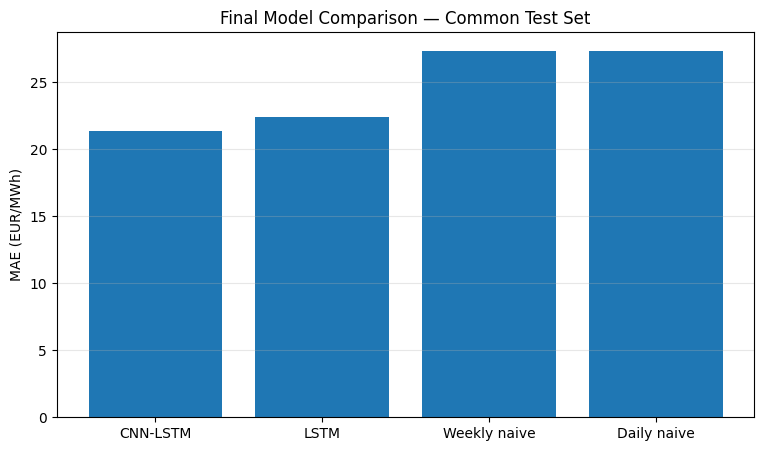

In [17]:
plot_df = (
    final_metrics
    .sort_values("MAE")
)

plt.figure(figsize=(9, 5))

plt.bar(
    plot_df["model"],
    plot_df["MAE"]
)

plt.ylabel("MAE (EUR/MWh)")
plt.title(
    "Final Model Comparison — Common Test Set"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

In [18]:
horizon_rows = []

for h in range(1, 25):

    subset = common[
        common["horizon"] == h
    ]

    row = {
        "horizon": h
    }

    for model_name, col in model_cols.items():

        row[model_name] = (
            mean_absolute_error(
                subset["actual"],
                subset[col]
            )
        )

    horizon_rows.append(row)

In [19]:
final_horizon_metrics = pd.DataFrame(
    horizon_rows
)

display(final_horizon_metrics)

,horizon,Daily naive,Weekly naive,LSTM,CNN-LSTM
0,1,27.350460,27.317535,19.123610,18.891054
1,2,27.347464,27.319416,20.893997,19.052874
2,3,27.337175,27.324619,22.209656,19.490601
3,4,27.326101,27.343571,23.190784,20.081036
4,5,27.329847,27.346621,23.449474,20.761616
5,6,27.333935,27.347061,24.703655,20.731739
6,7,27.331068,27.346394,24.299871,21.045658
7,8,27.324804,27.347208,24.170551,21.229145
8,9,27.320261,27.348776,23.999012,21.799551
9,10,27.324373,27.353571,23.670925,22.383795


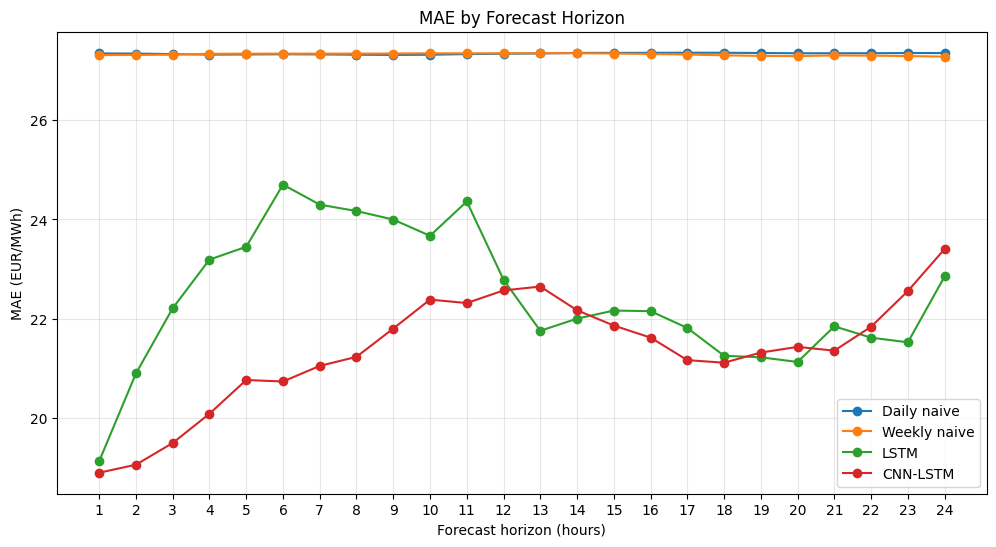

In [20]:
plt.figure(figsize=(12, 6))

for model_name in model_cols:

    plt.plot(
        final_horizon_metrics["horizon"],
        final_horizon_metrics[model_name],
        marker="o",
        label=model_name
    )

plt.xlabel(
    "Forecast horizon (hours)"
)

plt.ylabel(
    "MAE (EUR/MWh)"
)

plt.title(
    "MAE by Forecast Horizon"
)

plt.xticks(
    range(1, 25)
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [21]:
common["delivery_time_utc"] = (
    common["forecast_start"]
    + pd.to_timedelta(
        common["horizon"] - 1,
        unit="h"
    )
)

common["delivery_time_local"] = (
    common["delivery_time_utc"]
    .dt.tz_convert(
        "Europe/Berlin"
    )
)

common["delivery_time_local_iso"] = (
    common[
        "delivery_time_local"
    ]
    .map(
        lambda timestamp:
        timestamp.isoformat()
    )
)

common[
    "delivery_timezone_abbreviation"
] = (
    common[
        "delivery_time_local"
    ]
    .dt.strftime("%Z")
)

common["utc_offset"] = (
    common[
        "delivery_time_local"
    ]
    .dt.strftime("%z")
)

common["local_hour"] = (
    common[
        "delivery_time_local"
    ]
    .dt.hour
)

common["local_dow"] = (
    common[
        "delivery_time_local"
    ]
    .dt.dayofweek
)

common["weekend"] = (
    common["local_dow"] >= 5
)

In [22]:
DEPLOYMENT_ORIGIN_HOUR_UTC = 12

scheduled_12utc = (
    common[
        common[
            "forecast_start"
        ].dt.hour
        == DEPLOYMENT_ORIGIN_HOUR_UTC
    ]
    .copy()
    .sort_values(
        [
            "forecast_start",
            "horizon"
        ]
    )
)

if scheduled_12utc.empty:
    raise ValueError(
        "No 12:00 UTC forecasts found."
    )

scheduled_validation = (
    scheduled_12utc
    .groupby("forecast_start")
    .agg(
        rows=("horizon", "size"),
        unique_horizons=(
            "horizon",
            "nunique"
        ),
        first_horizon=(
            "horizon",
            "min"
        ),
        last_horizon=(
            "horizon",
            "max"
        )
    )
)

valid_scheduled_forecasts = (
    scheduled_validation[
        "rows"
    ].eq(24)
    & scheduled_validation[
        "unique_horizons"
    ].eq(24)
    & scheduled_validation[
        "first_horizon"
    ].eq(1)
    & scheduled_validation[
        "last_horizon"
    ].eq(24)
)

if not valid_scheduled_forecasts.all():
    raise ValueError(
        "Incomplete 12:00 UTC "
        "forecasts were detected."
    )

print(
    "Complete 12:00 UTC forecasts:",
    scheduled_12utc[
        "forecast_start"
    ].nunique()
)

Complete 12:00 UTC forecasts: 109


In [23]:
scheduled_metric_rows = []

for model_name, column in (
    model_cols.items()
):

    scores = evaluate(
        scheduled_12utc["actual"],
        scheduled_12utc[column]
    )

    scheduled_metric_rows.append(
        {
            "forecast_origin_hour_utc":
                DEPLOYMENT_ORIGIN_HOUR_UTC,

            "forecast_count":
                int(
                    scheduled_12utc[
                        "forecast_start"
                    ].nunique()
                ),

            "model":
                model_name,

            **scores
        }
    )

scheduled_12utc_metrics = (
    pd.DataFrame(
        scheduled_metric_rows
    )
    .sort_values(
        [
            "MAE",
            "RMSE"
        ]
    )
    .reset_index(drop=True)
)

display(
    scheduled_12utc_metrics
)

,forecast_origin_hour_utc,forecast_count,model,N,MAE,RMSE,sMAPE,MAPE_guarded,MAPE_excluded
0,12,109,CNN-LSTM,2616,21.023934,27.787628,48.060615,99.126103,140
1,12,109,LSTM,2616,22.275520,29.432293,48.039534,119.348696,140
2,12,109,Daily naive,2616,27.337301,38.577040,60.844267,112.757937,140
3,12,109,Weekly naive,2616,27.396456,37.250586,62.567861,115.499673,140


In [24]:
scheduled_horizon_rows = []

for horizon in range(1, 25):

    horizon_subset = (
        scheduled_12utc[
            scheduled_12utc[
                "horizon"
            ] == horizon
        ]
    )

    row = {
        "horizon": horizon
    }

    for model_name, column in (
        model_cols.items()
    ):

        row[model_name] = float(
            mean_absolute_error(
                horizon_subset["actual"],
                horizon_subset[column]
            )
        )

    scheduled_horizon_rows.append(
        row
    )

scheduled_12utc_horizon_metrics = (
    pd.DataFrame(
        scheduled_horizon_rows
    )
)

display(
    scheduled_12utc_horizon_metrics
)

,horizon,Daily naive,Weekly naive,LSTM,CNN-LSTM
0,1,34.910828,35.425320,20.015581,17.767874
1,2,34.128532,34.358711,25.296646,17.804220
2,3,31.712109,31.190184,31.873625,17.546919
3,4,28.401831,31.682203,32.457821,17.256422
4,5,23.366238,26.357525,25.292709,15.390443
5,6,32.164497,33.628166,22.835588,22.497999
6,7,45.486332,37.824219,34.905838,37.769753
7,8,27.916697,26.427156,22.881262,24.488310
8,9,14.792661,17.214127,14.256863,15.905814
9,10,13.856514,15.984036,11.379865,13.246438


In [25]:
hour_rows = []

for hour in range(24):

    subset = common[
        common["local_hour"] == hour
    ]

    row = {
        "hour": hour
    }

    for model_name, col in model_cols.items():

        row[model_name] = (
            mean_absolute_error(
                subset["actual"],
                subset[col]
            )
        )

    hour_rows.append(row)

In [26]:
final_hour_metrics = pd.DataFrame(
    hour_rows
)

display(final_hour_metrics)

,hour,Daily naive,Weekly naive,LSTM,CNN-LSTM
0,0,19.965719,22.861412,16.157589,17.072084
1,1,19.170763,21.500954,15.730782,16.350481
2,2,18.876789,21.079222,16.083393,16.243883
3,3,19.649931,20.964350,16.432367,16.271835
4,4,19.285927,22.060003,15.998759,16.302090
5,5,20.964853,24.057165,17.730625,17.478390
6,6,27.906744,25.603336,19.252092,20.300716
7,7,34.411083,24.089766,20.480368,23.192423
8,8,33.104641,23.735474,21.334208,19.079611
9,9,31.515882,26.803579,27.900265,21.300531


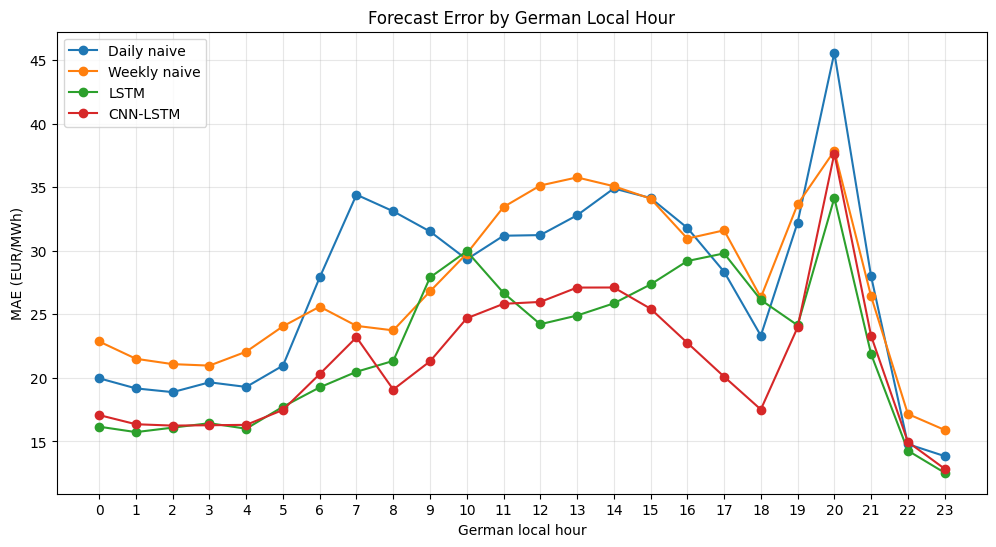

In [27]:
plt.figure(figsize=(12, 6))

for model_name in model_cols:

    plt.plot(
        final_hour_metrics["hour"],
        final_hour_metrics[model_name],
        marker="o",
        label=model_name
    )

plt.xlabel("German local hour")
plt.ylabel("MAE (EUR/MWh)")

plt.title(
    "Forecast Error by German Local Hour"
)

plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [28]:
weekday_weekend_rows = []

for label, mask in {
    "Weekday": ~common["weekend"],
    "Weekend": common["weekend"]
}.items():

    subset = common[mask]

    for model_name, col in model_cols.items():

        weekday_weekend_rows.append(
            {
                "period": label,
                "model": model_name,
                "MAE": mean_absolute_error(
                    subset["actual"],
                    subset[col]
                )
            }
        )

In [29]:
weekday_weekend_metrics = pd.DataFrame(
    weekday_weekend_rows
)

display(weekday_weekend_metrics)

,period,model,MAE
0,Weekday,Daily naive,26.371424
1,Weekday,Weekly naive,26.559288
2,Weekday,LSTM,21.146984
3,Weekday,CNN-LSTM,20.047043
4,Weekend,Daily naive,29.744225
5,Weekend,Weekly naive,29.228302
6,Weekend,LSTM,25.564573
7,Weekend,CNN-LSTM,24.614923


In [30]:
extreme_threshold = np.quantile(
    np.abs(common["actual"]),
    0.95
)

print(
    "Top-5% absolute-price threshold:",
    extreme_threshold
)

Top-5% absolute-price threshold: 139.0


In [31]:
extreme_mask = (
    np.abs(common["actual"])
    >= extreme_threshold
)

In [32]:
print(
    "Extreme observations:",
    extreme_mask.sum()
)

Extreme observations: 3144


In [33]:
negative_mask = (
    common["actual"] < 0
)

print(
    "Negative-price observations:",
    negative_mask.sum()
)

Negative-price observations: 5763


In [34]:
subset_rows = []

subsets = {
    "All": np.ones(
        len(common),
        dtype=bool
    ),

    "Top 5% absolute price":
        extreme_mask,

    "Negative price":
        negative_mask,

    "Weekday":
        ~common["weekend"],

    "Weekend":
        common["weekend"]
}

In [35]:
for subset_name, mask in subsets.items():

    subset = common.loc[mask]

    if len(subset) == 0:
        continue

    for model_name, col in model_cols.items():

        scores = evaluate(
            subset["actual"],
            subset[col]
        )

        subset_rows.append(
            {
                "subset": subset_name,
                "model": model_name,
                **scores
            }
        )

In [36]:
subset_metrics = pd.DataFrame(
    subset_rows
)

display(subset_metrics)

,subset,model,N,MAE,RMSE,sMAPE,MAPE_guarded,MAPE_excluded
0,All,Daily naive,62568,27.346263,38.609787,60.742546,112.829501,3336
1,All,Weekly naive,62568,27.330710,37.185778,62.341744,114.633077,3336
2,All,LSTM,62568,22.423798,29.913783,46.865641,121.750488,3336
3,All,CNN-LSTM,62568,21.367295,28.671335,46.990888,109.399248,3336
4,Top 5% absolute price,Daily naive,3144,51.617481,66.099721,37.861703,29.541138,0
5,Top 5% absolute price,Weekly naive,3144,40.430992,50.853411,26.072020,22.554320,0
6,Top 5% absolute price,LSTM,3144,42.512896,51.144035,26.956464,22.926925,0
7,Top 5% absolute price,CNN-LSTM,3144,48.111782,56.164498,31.343489,26.227337,0
8,Negative price,Daily naive,5763,34.082908,46.266209,167.941165,525.628619,2040
9,Negative price,Weekly naive,5763,38.142722,49.528530,170.131378,621.011397,2040


In [37]:
forecast_starts = (
    common["forecast_start"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

normal_start = forecast_starts.iloc[
    len(forecast_starts) // 2
]

In [38]:
example = (
    common[
        common["forecast_start"]
        == normal_start
    ]
    .sort_values("horizon")
)

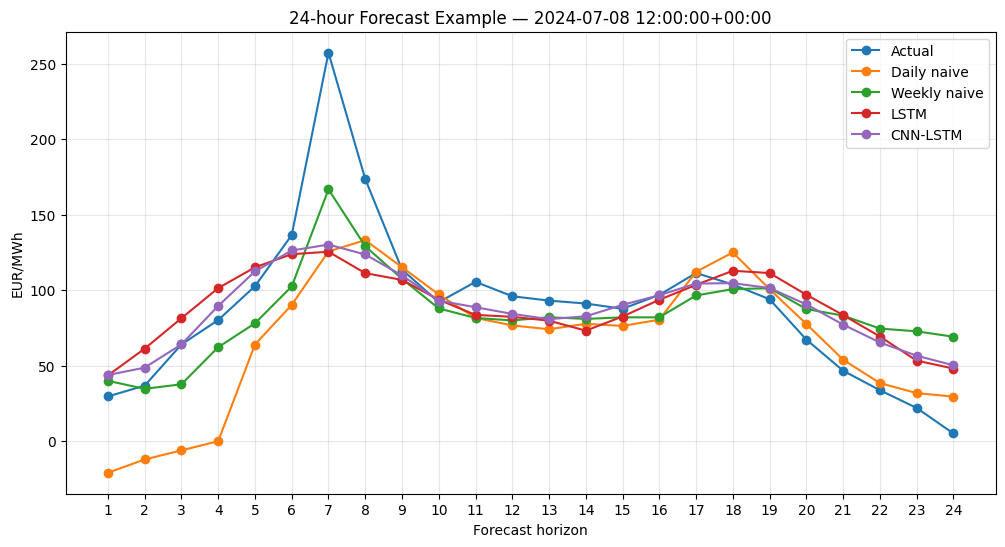

In [39]:
plt.figure(figsize=(12, 6))

plt.plot(
    example["horizon"],
    example["actual"],
    marker="o",
    label="Actual"
)

for model_name, col in model_cols.items():

    plt.plot(
        example["horizon"],
        example[col],
        marker="o",
        label=model_name
    )

plt.xlabel("Forecast horizon")
plt.ylabel("EUR/MWh")

plt.title(
    f"24-hour Forecast Example — {normal_start}"
)

plt.xticks(range(1, 25))
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [40]:
forecast_extremeness = (
    common
    .groupby("forecast_start")["actual"]
    .apply(
        lambda x:
        np.abs(x).max()
    )
)

In [41]:
spike_start = (
    forecast_extremeness.idxmax()
)

print(
    "Selected spike forecast:",
    spike_start
)

Selected spike forecast: 2024-08-28 19:00:00+00:00


In [42]:
spike_example = (
    common[
        common["forecast_start"]
        == spike_start
    ]
    .sort_values("horizon")
)

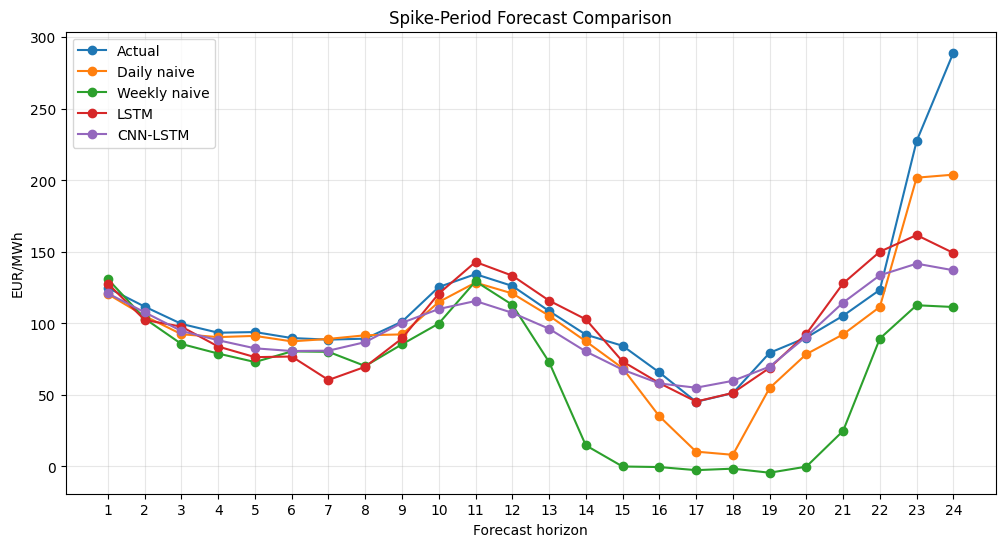

In [43]:
plt.figure(figsize=(12, 6))

plt.plot(
    spike_example["horizon"],
    spike_example["actual"],
    marker="o",
    label="Actual"
)

for model_name, col in model_cols.items():

    plt.plot(
        spike_example["horizon"],
        spike_example[col],
        marker="o",
        label=model_name
    )

plt.xlabel("Forecast horizon")
plt.ylabel("EUR/MWh")

plt.title(
    "Spike-Period Forecast Comparison"
)

plt.xticks(range(1, 25))
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [44]:
negative_forecasts = (
    common[
        common["actual"] < 0
    ]["forecast_start"]
    .drop_duplicates()
)

In [45]:
print(
    "Forecasts containing negative prices:",
    len(negative_forecasts)
)

Forecasts containing negative prices: 1060


In [46]:
if len(negative_forecasts) > 0:

    negative_start = (
        negative_forecasts.iloc[0]
    )

    negative_example = (
        common[
            common["forecast_start"]
            == negative_start
        ]
        .sort_values("horizon")
    )

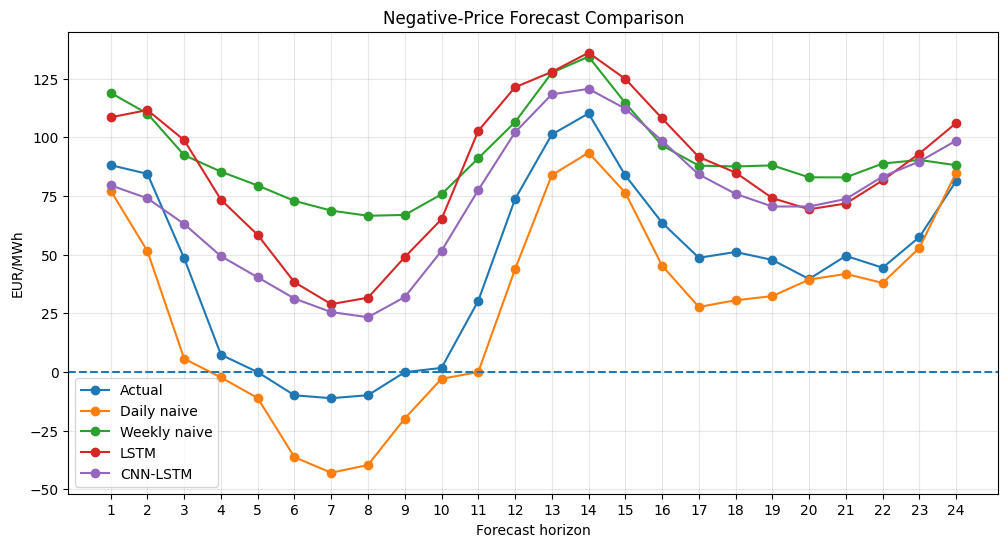

In [47]:
if len(negative_forecasts) > 0:

    plt.figure(figsize=(12, 6))

    plt.plot(
        negative_example["horizon"],
        negative_example["actual"],
        marker="o",
        label="Actual"
    )

    for model_name, col in model_cols.items():

        plt.plot(
            negative_example["horizon"],
            negative_example[col],
            marker="o",
            label=model_name
        )

    plt.axhline(
        0,
        linestyle="--"
    )

    plt.xlabel("Forecast horizon")
    plt.ylabel("EUR/MWh")

    plt.title(
        "Negative-Price Forecast Comparison"
    )

    plt.xticks(range(1, 25))
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

In [48]:
h1 = (
    common[
        common["horizon"] == 1
    ]
    .sort_values("delivery_time_utc")
)

In [49]:
start_position = max(
    0,
    len(h1) // 2 - 84
)

week_example = h1.iloc[
    start_position :
    start_position + 168
]

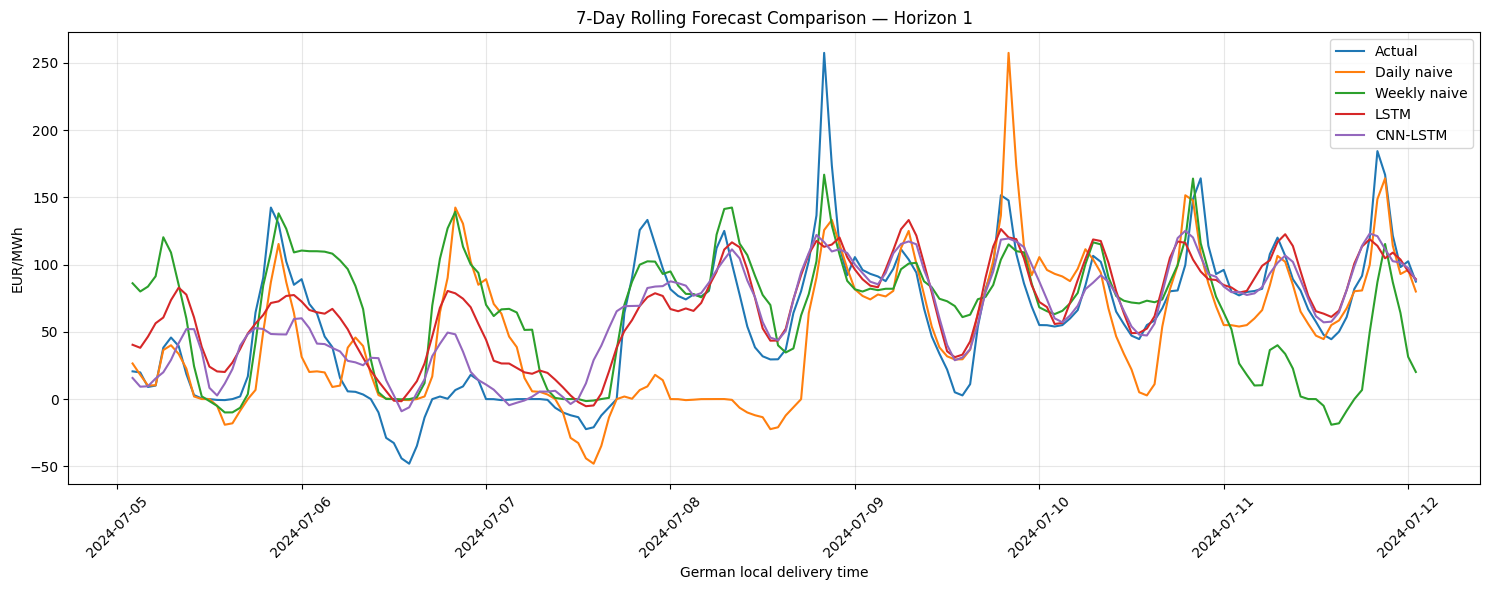

In [50]:
plt.figure(figsize=(15, 6))

plt.plot(
    week_example["delivery_time_local"],
    week_example["actual"],
    label="Actual"
)

for model_name, col in model_cols.items():

    plt.plot(
        week_example["delivery_time_local"],
        week_example[col],
        label=model_name
    )

plt.xlabel("German local delivery time")
plt.ylabel("EUR/MWh")

plt.title(
    "7-Day Rolling Forecast Comparison — Horizon 1"
)

plt.legend()
plt.grid(alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [51]:
def json_safe_number(value):

    if value is None:
        return None

    value = float(value)

    if not np.isfinite(value):
        return None

    return value

In [52]:
def build_forecast_evaluation_payload(
    evaluation_data,
    forecast_origin,
    prediction_column="cnn_lstm",
    model_version="cnn_lstm_frozen",
    data_class="historical_example",
    is_live=False
):
    forecast_origin = pd.Timestamp(
        forecast_origin
    )

    if forecast_origin.tz is None:
        raise ValueError(
            "Forecast origin must be "
            "timezone-aware."
        )

    forecast_origin = (
        forecast_origin.tz_convert("UTC")
    )

    forecast_rows = (
        evaluation_data[
            evaluation_data[
                "forecast_start"
            ] == forecast_origin
        ]
        .sort_values("horizon")
        .copy()
    )

    expected_horizons = list(
        range(1, 25)
    )

    if (
        len(forecast_rows) != 24
        or forecast_rows[
            "horizon"
        ].tolist() != expected_horizons
    ):
        raise ValueError(
            "Forecast must contain exactly "
            "horizons 1 through 24."
        )

    if forecast_rows[
        prediction_column
    ].isna().any():

        raise ValueError(
            "Forecast contains missing "
            "prediction values."
        )

    available_actual_hours = int(
        forecast_rows[
            "actual"
        ].notna().sum()
    )

    evaluation_complete = (
        available_actual_hours == 24
    )

    status = (
        "complete"
        if evaluation_complete
        else "pending"
    )

    forecast_rows = (
        forecast_rows.rename(
            columns={
                prediction_column:
                    "forecast_price_eur_mwh",

                "actual":
                    "actual_price_eur_mwh"
            }
        )
    )

    forecast_rows[
        "error_eur_mwh"
    ] = np.nan

    forecast_rows[
        "absolute_error_eur_mwh"
    ] = np.nan

    forecast_rows[
        "squared_error"
    ] = np.nan

    forecast_rows[
        "absolute_percentage_error_pct"
    ] = np.nan

    metric_payload = None

    if evaluation_complete:

        forecast_rows[
            "error_eur_mwh"
        ] = (
            forecast_rows[
                "forecast_price_eur_mwh"
            ]
            - forecast_rows[
                "actual_price_eur_mwh"
            ]
        )

        forecast_rows[
            "absolute_error_eur_mwh"
        ] = np.abs(
            forecast_rows[
                "error_eur_mwh"
            ]
        )

        forecast_rows[
            "squared_error"
        ] = (
            forecast_rows[
                "error_eur_mwh"
            ] ** 2
        )

        valid_mape = (
            np.abs(
                forecast_rows[
                    "actual_price_eur_mwh"
                ]
            )
            >= MAPE_MIN_ABS_ACTUAL
        )

        forecast_rows.loc[
            valid_mape,
            "absolute_percentage_error_pct"
        ] = (
            100
            * forecast_rows.loc[
                valid_mape,
                "absolute_error_eur_mwh"
            ]
            / np.abs(
                forecast_rows.loc[
                    valid_mape,
                    "actual_price_eur_mwh"
                ]
            )
        )

        scores = evaluate(
            forecast_rows[
                "actual_price_eur_mwh"
            ],
            forecast_rows[
                "forecast_price_eur_mwh"
            ]
        )

        metric_payload = {
            "mae_eur_mwh":
                json_safe_number(
                    scores["MAE"]
                ),

            "rmse_eur_mwh":
                json_safe_number(
                    scores["RMSE"]
                ),

            "smape_pct":
                json_safe_number(
                    scores["sMAPE"]
                ),

            "mape_guarded_pct":
                json_safe_number(
                    scores[
                        "MAPE_guarded"
                    ]
                ),

            "mape_excluded_hours":
                int(
                    scores[
                        "MAPE_excluded"
                    ]
                ),

            "evaluated_hours":
                int(scores["N"])
        }

    row_payload = []

    for row in (
        forecast_rows.itertuples()
    ):

        local_timestamp = (
            row.delivery_time_local
        )

        row_payload.append(
            {
                "horizon":
                    int(row.horizon),

                "delivery_time_utc":
                    row.delivery_time_utc
                    .isoformat(),

                "delivery_time_local":
                    local_timestamp
                    .isoformat(),

                "german_timezone":
                    local_timestamp
                    .strftime("%Z"),

                "forecast_price_eur_mwh":
                    json_safe_number(
                        row.forecast_price_eur_mwh
                    ),

                "actual_price_eur_mwh":
                    json_safe_number(
                        row.actual_price_eur_mwh
                    ),

                "error_eur_mwh":
                    json_safe_number(
                        row.error_eur_mwh
                    ),

                "absolute_error_eur_mwh":
                    json_safe_number(
                        row.absolute_error_eur_mwh
                    ),

                "absolute_percentage_error_pct":
                    json_safe_number(
                        row.absolute_percentage_error_pct
                    )
            }
        )

    payload = {
        "schema_version": "1.0",
        "data_class": data_class,
        "is_live": bool(is_live),
        "status": status,
        "model_version": model_version,

        "forecast_origin_utc":
            forecast_origin.isoformat(),

        "forecast_origin_local":
            forecast_origin
            .tz_convert(
                "Europe/Berlin"
            )
            .isoformat(),

        "delivery_timezone":
            "Europe/Berlin",

        "delivery_start_utc":
            forecast_rows[
                "delivery_time_utc"
            ].min().isoformat(),

        "delivery_end_utc":
            forecast_rows[
                "delivery_time_utc"
            ].max().isoformat(),

        "expected_hours": 24,

        "available_actual_hours":
            available_actual_hours,

        "metrics":
            metric_payload,

        "message": (
            "Evaluation complete."
            if evaluation_complete
            else
            "Evaluation is waiting for "
            "all 24 actual prices."
        ),

        "metric_notes": {
            "mape_guarded": (
                "MAPE excludes hours where "
                "|actual price| is below "
                f"{MAPE_MIN_ABS_ACTUAL} "
                "EUR/MWh."
            ),

            "smape": (
                "sMAPE is the preferred "
                "percentage metric for "
                "electricity prices containing "
                "zero or negative values."
            )
        },

        "rows": row_payload
    }

    return forecast_rows, payload

In [53]:
example_origin_12utc = (
    scheduled_12utc[
        "forecast_start"
    ].max()
)

(
    operational_example_rows,
    operational_example_payload
) = build_forecast_evaluation_payload(
    evaluation_data=scheduled_12utc,
    forecast_origin=example_origin_12utc,
    prediction_column="cnn_lstm",
    model_version=cnn_config.get(
        "model_version",
        "cnn_lstm_frozen"
    ),
    data_class="historical_example",
    is_live=False
)

print(
    operational_example_payload[
        "status"
    ]
)

print(
    operational_example_payload[
        "metrics"
    ]
)

display(
    operational_example_rows[
        [
            "horizon",
            "delivery_time_utc",
            "delivery_time_local",
            "forecast_price_eur_mwh",
            "actual_price_eur_mwh",
            "absolute_error_eur_mwh"
        ]
    ]
)

complete
{'mae_eur_mwh': 14.584605500102043, 'rmse_eur_mwh': 17.441382256221342, 'smape_pct': 55.98002075135574, 'mape_guarded_pct': 70.11971914095601, 'mape_excluded_hours': 2, 'evaluated_hours': 24}


,horizon,delivery_time_utc,delivery_time_local,forecast_price_eur_mwh,actual_price_eur_mwh,absolute_error_eur_mwh
62376,1,2024-08-31 12:00:00+00:00,2024-08-31 14:00:00+02:00,7.976282,-0.800000,8.776282
62377,2,2024-08-31 13:00:00+00:00,2024-08-31 15:00:00+02:00,18.503382,2.550000,15.953382
62378,3,2024-08-31 14:00:00+00:00,2024-08-31 16:00:00+02:00,40.487881,23.709999,16.777882
62379,4,2024-08-31 15:00:00+00:00,2024-08-31 17:00:00+02:00,70.441551,80.019997,9.578445
62380,5,2024-08-31 16:00:00+00:00,2024-08-31 18:00:00+02:00,95.996346,117.300003,21.303658
62381,6,2024-08-31 17:00:00+00:00,2024-08-31 19:00:00+02:00,112.348373,148.289993,35.941620
62382,7,2024-08-31 18:00:00+00:00,2024-08-31 20:00:00+02:00,118.485863,126.779999,8.294136
62383,8,2024-08-31 19:00:00+00:00,2024-08-31 21:00:00+02:00,107.481461,107.290001,0.191460
62384,9,2024-08-31 20:00:00+00:00,2024-08-31 22:00:00+02:00,98.890137,99.849998,0.959862
62385,10,2024-08-31 21:00:00+00:00,2024-08-31 23:00:00+02:00,86.201515,89.230003,3.028488


In [54]:
OUTPUT_DIR = Path(
    "/kaggle/working"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Full historical evaluation
final_metrics.to_csv(
    OUTPUT_DIR
    / "final_model_metrics.csv",
    index=False
)

final_horizon_metrics.to_csv(
    OUTPUT_DIR
    / "final_horizon_metrics.csv",
    index=False
)

final_hour_metrics.to_csv(
    OUTPUT_DIR
    / "final_hour_metrics.csv",
    index=False
)

subset_metrics.to_csv(
    OUTPUT_DIR
    / "subset_metrics.csv",
    index=False
)

weekday_weekend_metrics.to_csv(
    OUTPUT_DIR
    / "weekday_weekend_metrics.csv",
    index=False
)

common.to_parquet(
    OUTPUT_DIR
    / "common_test_predictions.parquet",
    index=False
)

# Historical evaluation matching
# the production schedule
scheduled_12utc_metrics.to_csv(
    OUTPUT_DIR
    / "scheduled_12utc_metrics.csv",
    index=False
)

scheduled_12utc_horizon_metrics.to_csv(
    OUTPUT_DIR
    / "scheduled_12utc_horizon_metrics.csv",
    index=False
)

scheduled_12utc.to_parquet(
    OUTPUT_DIR
    / "scheduled_12utc_predictions.parquet",
    index=False
)

# Historical API-schema example
operational_example_rows.to_parquet(
    OUTPUT_DIR
    / "operational_evaluation_example.parquet",
    index=False
)

with open(
    OUTPUT_DIR
    / "operational_evaluation_example.json",
    "w"
) as file:

    json.dump(
        operational_example_payload,
        file,
        indent=2,
        allow_nan=False
    )

print(
    "Notebook 6 outputs saved to:",
    OUTPUT_DIR
)

Notebook 6 outputs saved to: /kaggle/working


In [55]:
metrics_text = (
    final_metrics
    .sort_values("MAE")
    .to_markdown(index=False)
)

scheduled_metrics_text = (
    scheduled_12utc_metrics
    .sort_values("MAE")
    .to_markdown(index=False)
)

subset_text = (
    subset_metrics
    .to_markdown(index=False)
)

test_start = (
    common[
        "forecast_start"
    ].min().isoformat()
)

test_end = (
    common[
        "forecast_start"
    ].max().isoformat()
)

model_version = (
    cnn_config.get(
        "model_version",
        "cnn_lstm_frozen"
    )
)

summary = f"""---
document_id: static_model_evaluation_v1
document_type: static_model_documentation
model_version: {model_version}
dynamic_data: false
---

# Static Electricity Forecast Model Evaluation

## Document purpose

This document contains static historical information about the forecasting
models. It does not contain today's live forecast or yesterday's live
evaluation.

Dynamic production data must be retrieved separately from the backend.

## Production configuration

- Production model: CNN-LSTM
- Model version: {model_version}
- Forecast origin: 12:00 UTC
- Forecast horizon: 24 consecutive hours
- Engineered input window: 168 hours
- Minimum raw history required: 336 hours
- Canonical storage timezone: UTC
- Display timezone: Europe/Berlin
- Automatic retraining: disabled
- Target unit: EUR/MWh

## CNN-LSTM architecture

- First Conv1D filters: {cnn_config["conv1_filters"]}
- First Conv1D kernel: {cnn_config["conv1_kernel"]}
- Pool size: {cnn_config["pool_size"]}
- Second Conv1D filters: {cnn_config["conv2_filters"]}
- Second Conv1D kernel: {cnn_config["conv2_kernel"]}
- LSTM units: {cnn_config["lstm_units"]}
- LSTM dropout: {cnn_config["lstm_dropout"]}
- Dense units: {cnn_config["dense_units"]}
- Dense dropout: {cnn_config["dense_dropout"]}
- Forecast outputs: 24

## Historical evaluation period

- First forecast origin: {test_start}
- Last forecast origin: {test_end}

These dates refer to historical offline evaluation and must not be interpreted
as current production dates.

## Full historical test metrics

{metrics_text}

These metrics use all available hourly forecast origins.

## Historical 12:00 UTC metrics

{scheduled_metrics_text}

These metrics only use forecasts issued at 12:00 UTC and therefore correspond
more closely to the planned deployment schedule.

## Historical subset evaluation

{subset_text}

## Metric definitions

MAE is the mean absolute error in EUR/MWh.

RMSE is the square root of mean squared error in EUR/MWh and gives additional
weight to large forecast errors.

sMAPE is the symmetric mean absolute percentage error.

Guarded MAPE excludes observations where the absolute actual price is below
{MAPE_MIN_ABS_ACTUAL} EUR/MWh. The excluded observation count must always be
reported with guarded MAPE.

## Model-selection interpretation

CNN-LSTM has lower overall historical MAE and RMSE than the basic LSTM, but it
does not outperform the LSTM for every metric, forecast horizon or price
condition.

Its selection should be described as primarily based on validation performance,
overall MAE and overall RMSE.

## Input rules

The production model requires exactly 168 complete engineered hourly rows.

The raw-data pipeline requires at least 336 continuous hours because the
feature calculations require a 168-hour warm-up period.

The model uses historical actual load and historical forecast-load values. It
does not use future actual load.

Missing input values must cause the production prediction to fail safely.
The backend must not refit scalers or silently invent missing model inputs.

## Methodological limitations

The historical test period was inspected during model development and should
be described as a development evaluation rather than a fully untouched
publication-grade holdout.

Forecast windows near chronological split boundaries contain overlapping
24-hour target periods. Completely correcting the training boundary would
require a future retraining experiment.

Historical performance does not guarantee current performance. Production
performance must be recalculated daily using the previous scheduled forecast
and its corresponding 24 actual prices.

## Static and dynamic RAG separation

Static retrieval may use this document for:

- architecture questions
- feature questions
- historical model performance
- metric definitions
- model limitations

Dynamic questions must use the backend for:

- today's latest forecast
- yesterday's forecast
- yesterday's actual prices
- yesterday's MAE
- yesterday's RMSE
- yesterday's sMAPE
- yesterday's guarded MAPE
- evaluation availability status

Dynamic values must never be inferred from the historical example payload.
"""

STATIC_DOCUMENT_PATH = (
    OUTPUT_DIR
    / "static_model_evaluation.md"
)

with open(
    STATIC_DOCUMENT_PATH,
    "w"
) as file:

    file.write(summary)

print(
    "Static document saved:",
    STATIC_DOCUMENT_PATH
)

Static document saved: /kaggle/working/static_model_evaluation.md


In [56]:
assert len(
    operational_example_payload[
        "rows"
    ]
) == 24

assert [
    row["horizon"]
    for row in operational_example_payload[
        "rows"
    ]
] == list(range(1, 25))

utc_delivery_times = [
    row["delivery_time_utc"]
    for row in operational_example_payload[
        "rows"
    ]
]

assert len(
    set(utc_delivery_times)
) == 24

assert (
    operational_example_payload[
        "data_class"
    ]
    == "historical_example"
)

assert (
    operational_example_payload[
        "is_live"
    ]
    is False
)

assert (
    operational_example_payload[
        "status"
    ]
    == "complete"
)

assert (
    operational_example_payload[
        "metrics"
    ][
        "evaluated_hours"
    ]
    == 24
)

# Verify strict JSON compatibility.
json.dumps(
    operational_example_payload,
    allow_nan=False
)

assert STATIC_DOCUMENT_PATH.exists()

assert (
    scheduled_12utc[
        "forecast_start"
    ].dt.hour
    .eq(12)
    .all()
)

print(
    "Notebook 6 validation passed."
)

print(
    "Notebook 6 outputs are ready "
    "for the new RAG pipeline."
)

Notebook 6 validation passed.
Notebook 6 outputs are ready for the new RAG pipeline.
